# CPE 342 - Lab 07: Dimensionality Reduction

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |
| Tithinan Sobking | 67070501018 |
| Thanaboon Tikaew | 67070501021 |
| Worawut Sereethai | 67070501040 |
| Chanon Lhumsa-ard | 67070501059 |
| Siriwan Yindeephot | 67070501075 |

### Overview
- **Method**: linear PCA from scratch (eigendecomposition of the covariance matrix), cross-checked against `sklearn.decomposition.PCA`.
- **Dataset**: a 12-point toy set (Part I) and `MTCARS`, 32 cars x 11 features (Part II).
- **Objective**: answer Questions 2.1 and 2.2 - how many PCs reach about 90% of the variance, which features load on PC1, and whether standardising matters.
- **Additions**: sections headed *Additional analysis* add plots, a rank-1 reconstruction, a k-means clustering on PC1 and a summary.
- **Terms**: *loading* = a feature's entry in a unit-length PC (sign arbitrary, so magnitudes are compared); *PVE* = eigenvalue / total variance; *score* = an observation's coordinate along a PC. Loadings and PVEs are unitless.

---

# LAB: Dimensionality Reduction

**Load necessary packages and apply custom configurations**

In [1]:
import warnings; 
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore",category=UserWarning)
warnings.simplefilter(action="ignore",category=FutureWarning)

# Interactive plots embedded within the notebook
#%matplotlib notebook 
# Static images of plots embedded within the notebook
# %matplotlib inline   
%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from scipy import stats

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from platform import python_version

#pd.options.plotting.backend = "plotly" 
# Conflict with options in original matplotlib.

print('Python version', python_version())
print('Numpy version', np.__version__)
print('Scipy version', sp.__version__)
print('Pandas version', pd.__version__)
print('Matplotlib version', mpl.__version__)
print('Seaborn version', sns.__version__)
###############################################

#plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['grid.linestyle'] = ':'   
plt.rcParams['axes.grid'] = False

sns.set_style("whitegrid", {'axes.grid' : False})
#sns.color_palette("RdBu", n_colors=10)
#sns.color_palette("RdBu_r') # Good for heatmap

Python version 3.12.10
Numpy version 2.5.3
Scipy version 1.18.1
Pandas version 3.0.5
Matplotlib version 3.11.1
Seaborn version 0.13.2


# Part I: Linear PCA

**Create a dataset**   
rows = instances, columns = features/variables  

In [2]:
x1 = np.array([9,15,25,14,10,18,0,16,5,19,16,20])
x2 = np.array([39,56,93,61,50,75,32,85,42,70,66,80])

D = np.vstack((x1,x2)).T 
print(D)

[[ 9 39]
 [15 56]
 [25 93]
 [14 61]
 [10 50]
 [18 75]
 [ 0 32]
 [16 85]
 [ 5 42]
 [19 70]
 [16 66]
 [20 80]]


<font color='blue'>Make the dataset zero-mean by subtracting each column by its mean.

In [3]:
np.set_printoptions(suppress=True, precision=4)

X = D - D.mean(axis=0)
print(X)

[[ -4.9167 -23.4167]
 [  1.0833  -6.4167]
 [ 11.0833  30.5833]
 [  0.0833  -1.4167]
 [ -3.9167 -12.4167]
 [  4.0833  12.5833]
 [-13.9167 -30.4167]
 [  2.0833  22.5833]
 [ -8.9167 -20.4167]
 [  5.0833   7.5833]
 [  2.0833   3.5833]
 [  6.0833  17.5833]]


<font color='blue'>Compute the sample covariance matrix $S$ from the zero-mean data using `np.cov`.  
    
   
Use the option `rowvar=False` to treat the variables column-wise.  
The sum is divided by  $N-1$ by default (option `bias=False` or `ddof=1`)

In [4]:
S = np.cov(X, rowvar=False)
print(S)

[[ 47.7197 122.947 ]
 [122.947  370.0833]]


<font color='blue'>Compute the eigenpairs of the covariance matrix $S$ to get the principal components.  
Show the eigenvectors sorted by the largest eigenvalues first, and the corresponding eigenvalues.

In [5]:
# eigh, not eig: S is symmetric, and eig returns complex128 in this numpy. eigh sorts ascending, so reverse.
eigvals, eigvecs = np.linalg.eigh(S)
eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]

print('Eigenvalues, largest first (variance along each PC, in squared data units):')
print(eigvals)
print('\nEigenvectors, one per column (the sign of each is arbitrary):')
print(eigvecs)

Eigenvalues, largest first (variance along each PC, in squared data units):
[411.6219   6.1812]

Eigenvectors, one per column (the sign of each is arbitrary):
[[ 0.3201 -0.9474]
 [ 0.9474  0.3201]]


<font color='blue'>Take $r=2$ principal components as the matrix `Pr`

In [6]:
r = 2
Pr = eigvecs[:, :r]
print(Pr)

[[ 0.3201 -0.9474]
 [ 0.9474  0.3201]]


<font color='blue'>Transform the data to obtain the reduced-dimension data `Z` by multiplying  
    the zero-mean data $X$ to the matrix of principal components $Pr$.

In [7]:
Z = X @ Pr
print(Z)

# The transformation diagonalises the covariance: the scores are uncorrelated and their variances are the eigenvalues.

[[-23.7584  -2.8373]
 [ -5.7323  -3.0802]
 [ 32.5219  -0.711 ]
 [ -1.3155  -0.5324]
 [-13.0171  -0.2637]
 [ 13.2283   0.1592]
 [-33.2709   3.4487]
 [ 22.0621   5.2548]
 [-22.1966   1.9125]
 [  8.8115  -2.3886]
 [  4.0617  -0.8268]
 [ 18.6054  -0.1352]]


<font color='blue'>Reverse-transform the data by multiplying the transformed data and the matrix of principal components. 

In [8]:
X_rec = Z @ Pr.T            # r = d = 2, so nothing is lost: the reconstruction is exact
print('Reconstructed zero-mean data (equals X):')
print(X_rec)

D_rec = X_rec + D.mean(axis=0)            # add the mean back to return to the original units
print('\nWith the mean added back (equals D):')
print(D_rec)

Reconstructed zero-mean data (equals X):
[[ -4.9167 -23.4167]
 [  1.0833  -6.4167]
 [ 11.0833  30.5833]
 [  0.0833  -1.4167]
 [ -3.9167 -12.4167]
 [  4.0833  12.5833]
 [-13.9167 -30.4167]
 [  2.0833  22.5833]
 [ -8.9167 -20.4167]
 [  5.0833   7.5833]
 [  2.0833   3.5833]
 [  6.0833  17.5833]]

With the mean added back (equals D):
[[ 9. 39.]
 [15. 56.]
 [25. 93.]
 [14. 61.]
 [10. 50.]
 [18. 75.]
 [ 0. 32.]
 [16. 85.]
 [ 5. 42.]
 [19. 70.]
 [16. 66.]
 [20. 80.]]


<font color='blue'>Determine the variance explained by each principal component from the eigenvalues, 
the PVEs and the cumulative PVEs from the eigenvalues. 

In [9]:
from sklearn.decomposition import PCA

total_var = eigvals.sum()
pve = eigvals / total_var
cum_pve = np.cumsum(pve)

print(f'Total variance = trace(S) = {total_var:.2f} (squared data units)')
for k in range(len(eigvals)):
    print(f'PC{k + 1}: variance {eigvals[k]:8.4f}   PVE {pve[k]:.4f}   cumulative PVE {cum_pve[k]:.4f}')

Total variance = trace(S) = 417.80 (squared data units)
PC1: variance 411.6219   PVE 0.9852   cumulative PVE 0.9852
PC2: variance   6.1812   PVE 0.0148   cumulative PVE 1.0000


### Additional analysis - Part I

**A1. Principal axes.** Each line spans two standard deviations either side of the origin along a PC.

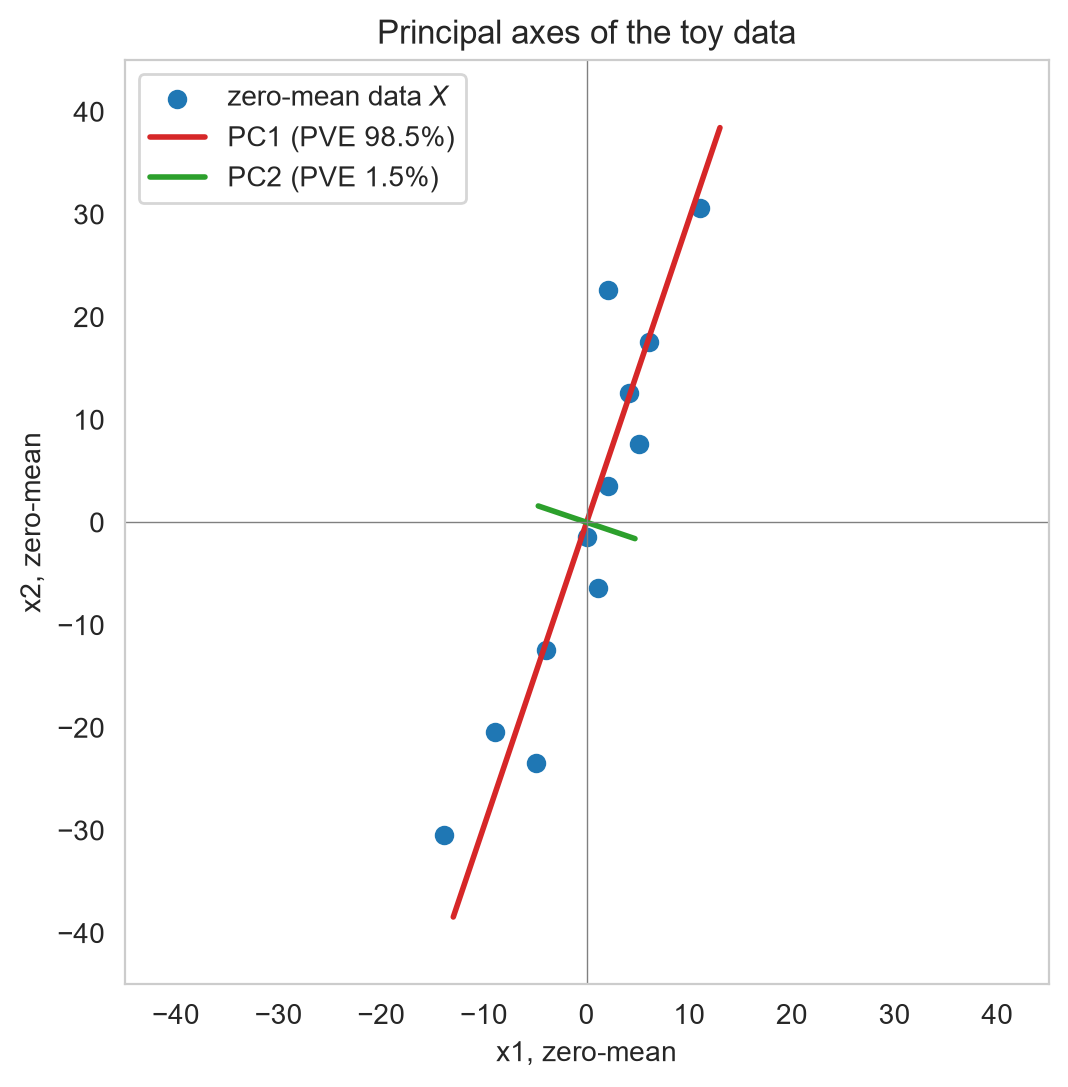

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], color='tab:blue', label='zero-mean data $X$')
for k, colour in enumerate(['tab:red', 'tab:green']):
    half = 2 * np.sqrt(eigvals[k])
    ax.plot([-half * eigvecs[0, k], half * eigvecs[0, k]], [-half * eigvecs[1, k], half * eigvecs[1, k]],
            color=colour, lw=2, label=f'PC{k + 1} (PVE {pve[k]:.1%})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_aspect('equal')
ax.set_xlim(-45, 45)      # square limits: equal aspect keeps PC1 and PC2 looking perpendicular
ax.set_ylim(-45, 45)
ax.set_xlabel('x1, zero-mean')
ax.set_ylabel('x2, zero-mean')
ax.set_title('Principal axes of the toy data')
ax.legend(loc='upper left')
plt.show();      # the trailing semicolon stops the notebook echoing every plotting call

**A2. Rank-1 reconstruction.** With r = d the reconstruction was exact. Keeping only PC1 projects every point onto the PC1 line; what is lost is the variance along PC2, the second eigenvalue.

Sum of squared residuals / (n - 1) = 6.1812 = lambda_2 = 6.1812 (squared data units)
Share of the total variance lost = 1.48% (= 1 - cumulative PVE of PC1)


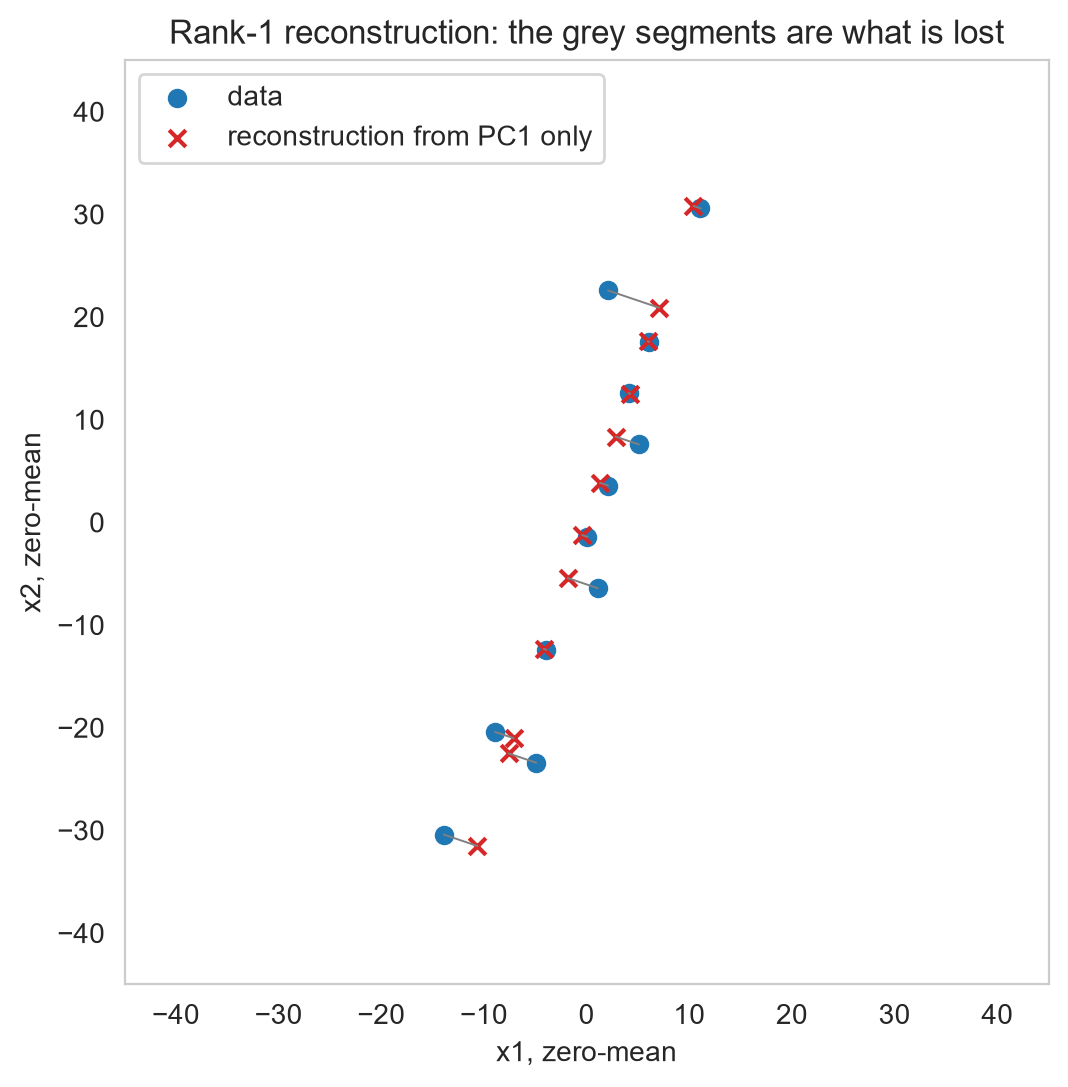

In [11]:
Pr1 = eigvecs[:, :1]
X_rec1 = (X @ Pr1) @ Pr1.T
lost = ((X - X_rec1) ** 2).sum() / (len(X) - 1)
print(f'Sum of squared residuals / (n - 1) = {lost:.4f} = lambda_2 = {eigvals[1]:.4f} (squared data units)')
print(f'Share of the total variance lost = {eigvals[1] / total_var:.2%} (= 1 - cumulative PVE of PC1)')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], color='tab:blue', label='data')
ax.scatter(X_rec1[:, 0], X_rec1[:, 1], color='tab:red', marker='x', label='reconstruction from PC1 only')
for original, rebuilt in zip(X, X_rec1):
    ax.plot([original[0], rebuilt[0]], [original[1], rebuilt[1]], color='grey', lw=0.7)
ax.set_aspect('equal')
ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_xlabel('x1, zero-mean')
ax.set_ylabel('x2, zero-mean')
ax.set_title('Rank-1 reconstruction: the grey segments are what is lost')
ax.legend(loc='upper left')
plt.show();

# Part II: Dimensionaltiy reduction with PCA

The dataset from sheet `MTCARS` in file `dimensionality-reduction.xlsx`. The dataset contains 11 columns:
- `mpg`: Miles per gallon (Fuel efficience)
- `cyl`: Number of cyclinders  
- `disp`: Displacement (Proxy to power generated by engine)  
- `hp`: Gross horse power  (Engine power output)
- `drat`: Rear axle ratio (# turns of the drive shaft for every one rotation of the wheel axle). 
          High ratio = More torque
- `wt`: Weight in 1000lbs
- `qsec`: 1/4 mile time (Fastest time to travel 1/4 mile in seconds)
- `vs`: Engine cylinder configuration (V-shape or Straight line)
- `am`: Transmission Type (Automatic or Manual)
- `gear`: Number of forward gears
- `carb`: Number of carburetors. Engines with higher displacement typically have higher barrel configuration

Load and explore the dataset

In [12]:
cars = pd.read_excel('dimensionality-reduction.xlsx', sheet_name='MTCARS')
print(f'{cars.shape[0]} cars x {cars.shape[1]} features')
cars.head()
cars.describe().T[['mean', 'std', 'min', 'max']]

32 cars x 11 features


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


,mean,std,min,max
mpg,20.090625,6.026948,10.400,33.900
cyl,6.187500,1.785922,4.000,8.000
disp,230.721875,123.938694,71.100,472.000
hp,146.687500,68.562868,52.000,335.000
drat,3.596563,0.534679,2.760,4.930
wt,3.217250,0.978457,1.513,5.424
qsec,17.848750,1.786943,14.500,22.900
vs,0.437500,0.504016,0.000,1.000
am,0.406250,0.498991,0.000,1.000
gear,3.687500,0.737804,3.000,5.000


Compute the covariance matrix of the dataset

In [13]:
S_raw = np.cov(cars, rowvar=False)        # np.cov centres each column itself
S_raw_df = pd.DataFrame(S_raw, index=cars.columns, columns=cars.columns)
print('Variances sit on the diagonal, each in its own squared unit; the largest are disp and hp.')
S_raw_df.round(2)

Variances sit on the diagonal, each in its own squared unit; the largest are disp and hp.


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,36.32,-9.17,-633.10,-320.73,2.20,-5.12,4.51,2.02,1.80,2.14,-5.36
cyl,-9.17,3.19,199.66,101.93,-0.67,1.37,-1.89,-0.73,-0.47,-0.65,1.52
disp,-633.10,199.66,15360.80,6721.16,-47.06,107.68,-96.05,-44.38,-36.56,-50.80,79.07
hp,-320.73,101.93,6721.16,4700.87,-16.45,44.19,-86.77,-24.99,-8.32,-6.36,83.04
drat,2.20,-0.67,-47.06,-16.45,0.29,-0.37,0.09,0.12,0.19,0.28,-0.08
wt,-5.12,1.37,107.68,44.19,-0.37,0.96,-0.31,-0.27,-0.34,-0.42,0.68
qsec,4.51,-1.89,-96.05,-86.77,0.09,-0.31,3.19,0.67,-0.20,-0.28,-1.89
vs,2.02,-0.73,-44.38,-24.99,0.12,-0.27,0.67,0.25,0.04,0.08,-0.46
am,1.80,-0.47,-36.56,-8.32,0.19,-0.34,-0.20,0.04,0.25,0.29,0.05
gear,2.14,-0.65,-50.80,-6.36,0.28,-0.42,-0.28,0.08,0.29,0.54,0.33


Compute the eigenvectors and the eigenvalues of the covariance matrix

In [14]:
def eig_desc(S):
    # Eigenpairs of a symmetric matrix, largest eigenvalue first (eigh for the reason given in Part I).
    values, vectors = np.linalg.eigh(S)
    return values[::-1], vectors[:, ::-1]

def pc_names(n):
    return [f'PC{k + 1}' for k in range(n)]

evals_raw, evecs_raw = eig_desc(S_raw)
loadings_raw = pd.DataFrame(evecs_raw, index=cars.columns, columns=pc_names(11))
print('Eigenvalues, largest first (variance along each PC):')
print(evals_raw.round(4))
print('\nEigenvectors, one PC per column. Entries are loadings (unitless); signs are arbitrary:')
loadings_raw.round(3)

Eigenvalues, largest first (variance along each PC):
[18641.2732  1455.2758     9.4311     1.7073     0.8217     0.4403
     0.0952     0.0818     0.0628     0.0444     0.0394]

Eigenvectors, one PC per column. Entries are loadings (unitless); signs are arbitrary:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
mpg,-0.038,0.009,-0.982,-0.048,0.088,-0.144,0.039,0.023,0.003,0.031,0.016
cyl,0.012,-0.003,0.063,0.228,-0.239,-0.794,-0.425,-0.189,-0.043,0.132,-0.145
disp,0.900,0.435,-0.031,0.005,0.011,0.007,-0.001,-0.001,-0.004,-0.005,-0.001
hp,0.435,-0.899,-0.025,-0.036,-0.017,0.002,0.002,0.000,0.004,0.002,0.002
drat,-0.003,-0.004,-0.040,0.057,0.133,0.227,-0.035,-0.939,0.014,0.184,0.097
wt,0.006,0.005,0.085,-0.128,0.244,-0.127,0.187,0.156,0.391,0.830,0.020
qsec,-0.007,0.025,0.072,-0.886,0.214,-0.190,-0.255,-0.103,0.096,-0.204,-0.011
vs,-0.003,0.002,-0.004,-0.177,0.017,0.103,0.081,-0.002,-0.684,0.303,-0.626
am,-0.002,-0.006,-0.055,0.136,0.063,0.205,-0.201,-0.023,0.572,-0.163,-0.733
gear,-0.003,-0.011,-0.049,0.130,0.276,0.335,-0.802,0.217,-0.156,0.204,0.191


Computer the PVE of principal components

In [15]:
def pve_table(evals):
    pve = evals / evals.sum()
    return pd.DataFrame({'eigenvalue': evals, 'PVE': pve, 'cumulative PVE': np.cumsum(pve)},
                        index=pc_names(len(evals)))

pve_raw = pve_table(evals_raw)
print(pve_raw.round(4).to_string())
print('\nPC1 loadings (unitless), largest magnitude first:')
print(loadings_raw['PC1'].reindex(loadings_raw['PC1'].abs().sort_values(ascending=False).index).round(3).to_string())

# "Large" loading for the written answer: |loading| >= 1/sqrt(11)
LARGE = 1 / np.sqrt(cars.shape[1])        # 0.30: the loading each feature would have if all 11 contributed equally
large_raw = loadings_raw['PC1'].abs()[lambda s: s >= LARGE].sort_values(ascending=False)
print(f'\nFeatures with |loading| >= {LARGE:.2f} in PC1:', list(large_raw.index))

      eigenvalue     PVE  cumulative PVE
PC1   18641.2732  0.9270          0.9270
PC2    1455.2758  0.0724          0.9994
PC3       9.4311  0.0005          0.9998
PC4       1.7073  0.0001          0.9999
PC5       0.8217  0.0000          1.0000
PC6       0.4403  0.0000          1.0000
PC7       0.0952  0.0000          1.0000
PC8       0.0818  0.0000          1.0000
PC9       0.0628  0.0000          1.0000
PC10      0.0444  0.0000          1.0000
PC11      0.0394  0.0000          1.0000

PC1 loadings (unitless), largest magnitude first:
disp    0.900
hp      0.435
mpg    -0.038
cyl     0.012
qsec   -0.007
wt      0.006
carb    0.006
vs     -0.003
drat   -0.003
gear   -0.003
am     -0.002

Features with |loading| >= 0.30 in PC1: ['disp', 'hp']


**<font color='darkorange'>Question 2.1</font>**
- (a) How many PCs are sufficient to explain at least approximately 90% of the total variation in the data ?
- (b) Which of the original features get large weights (loadings) in PC1 ?

**Answer 2.1**
- **(a)** One PC. PC1 alone has a PVE of 92.7%; PC1 + PC2 reach 99.9%.
- **(b)** Only `disp` (0.900) and `hp` (0.435). "Large" means |loading| ≥ 0.30 (= 1/√11, the loading each of the 11 features would have if all contributed equally); every other feature is ≤ 0.04.

Standardize the data with `StandardScaler()` in scikit-learn.

In [16]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(cars)      # StandardScaler divides by n when it computes the standard deviation
print('Every standardised feature now has mean 0 and standard deviation 1 (unitless).')

Every standardised feature now has mean 0 and standard deviation 1 (unitless).


Compute the covariance matrix of the standardized dataset

In [17]:
S_std = np.cov(X_std, rowvar=False)
print('Diagonal of the covariance matrix of the standardised data (first three shown, all equal):', np.diag(S_std)[:3].round(4))
pd.DataFrame(S_std, index=cars.columns, columns=cars.columns).round(2)

Diagonal of the covariance matrix of the standardised data (first three shown, all equal): [1.0323 1.0323 1.0323]


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.03,-0.88,-0.87,-0.80,0.70,-0.90,0.43,0.69,0.62,0.50,-0.57
cyl,-0.88,1.03,0.93,0.86,-0.72,0.81,-0.61,-0.84,-0.54,-0.51,0.54
disp,-0.87,0.93,1.03,0.82,-0.73,0.92,-0.45,-0.73,-0.61,-0.57,0.41
hp,-0.80,0.86,0.82,1.03,-0.46,0.68,-0.73,-0.75,-0.25,-0.13,0.77
drat,0.70,-0.72,-0.73,-0.46,1.03,-0.74,0.09,0.45,0.74,0.72,-0.09
wt,-0.90,0.81,0.92,0.68,-0.74,1.03,-0.18,-0.57,-0.71,-0.60,0.44
qsec,0.43,-0.61,-0.45,-0.73,0.09,-0.18,1.03,0.77,-0.24,-0.22,-0.68
vs,0.69,-0.84,-0.73,-0.75,0.45,-0.57,0.77,1.03,0.17,0.21,-0.59
am,0.62,-0.54,-0.61,-0.25,0.74,-0.71,-0.24,0.17,1.03,0.82,0.06
gear,0.50,-0.51,-0.57,-0.13,0.72,-0.60,-0.22,0.21,0.82,1.03,0.28


Compute the eigenvectors and the eigenvalues of the covariance matrix

In [18]:
evals_std, evecs_std = eig_desc(S_std)
loadings_std = pd.DataFrame(evecs_std, index=cars.columns, columns=pc_names(11))
print('Eigenvalues, largest first:')
print(evals_std.round(4))
# np.cov divides by n - 1 but StandardScaler divided by n, so these add up to 11 * 32/31 = 11.3548, not 11 (see the note below).
print('\nSum of the eigenvalues:', evals_std.sum().round(4))
print('\nLoadings (unitless), one PC per column:')
loadings_std.round(3)

Eigenvalues, largest first:
[6.8216 2.736  0.6474 0.2783 0.2307 0.2184 0.1396 0.1269 0.0795 0.0537
 0.0228]

Sum of the eigenvalues: 11.3548

Loadings (unitless), one PC per column:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
mpg,-0.363,-0.016,0.226,-0.023,-0.103,0.109,-0.368,0.754,-0.236,-0.139,0.125
cyl,0.374,-0.044,0.175,-0.003,-0.058,-0.169,-0.057,0.231,-0.054,0.846,0.141
disp,0.368,0.049,0.061,0.257,-0.394,0.336,-0.214,-0.001,-0.198,-0.049,-0.661
hp,0.330,-0.249,-0.140,-0.068,-0.540,-0.071,0.001,0.222,0.576,-0.248,0.256
drat,-0.294,-0.275,-0.161,0.855,-0.077,-0.244,-0.021,-0.032,0.047,0.101,0.040
wt,0.346,0.143,-0.342,0.246,0.075,0.465,0.021,0.009,-0.359,-0.094,0.567
qsec,-0.200,0.463,-0.403,0.068,0.165,0.330,-0.050,0.232,0.528,0.271,-0.181
vs,-0.307,0.232,-0.429,-0.215,-0.600,-0.194,0.266,-0.026,-0.359,0.159,-0.008
am,-0.235,-0.429,0.206,-0.030,-0.090,0.571,0.587,0.060,0.047,0.178,-0.030
gear,-0.207,-0.462,-0.290,-0.265,-0.048,0.244,-0.605,-0.336,0.002,0.214,0.054


Computer the PVE of principal components

In [19]:
pve_std = pve_table(evals_std)
print(pve_std.round(4).to_string())
print('\nPC1 loadings (unitless), largest magnitude first:')
print(loadings_std['PC1'].reindex(loadings_std['PC1'].abs().sort_values(ascending=False).index).round(3).to_string())

# Same "large" loading rule as in Question 2.1
large_std = loadings_std['PC1'].abs()[lambda s: s >= LARGE].sort_values(ascending=False)
print(f'\nFeatures with |loading| >= {LARGE:.2f} in PC1:', list(large_std.index))

      eigenvalue     PVE  cumulative PVE
PC1       6.8216  0.6008          0.6008
PC2       2.7360  0.2410          0.8417
PC3       0.6474  0.0570          0.8987
PC4       0.2783  0.0245          0.9232
PC5       0.2307  0.0203          0.9436
PC6       0.2184  0.0192          0.9628
PC7       0.1396  0.0123          0.9751
PC8       0.1269  0.0112          0.9863
PC9       0.0795  0.0070          0.9933
PC10      0.0537  0.0047          0.9980
PC11      0.0228  0.0020          1.0000

PC1 loadings (unitless), largest magnitude first:
cyl     0.374
disp    0.368
mpg    -0.363
wt      0.346
hp      0.330
vs     -0.307
drat   -0.294
am     -0.235
carb    0.214
gear   -0.207
qsec   -0.200

Features with |loading| >= 0.30 in PC1: ['cyl', 'disp', 'mpg', 'wt', 'hp', 'vs']


**Note**: the eigenvalues sum to 11.355, not 11. `StandardScaler` divides by n (32) but `np.cov` by n - 1 (31), so each variance is 32/31. PVE is a ratio, so it is unaffected.

**<font color='darkorange'>Question 2.2</font>**
- (a) How many PCs are sufficient to explain at least approximately 90% of the total variation in the data ?
- (b) Which of the original features get large weights (loadings) in PC1 ?
- (c) Do the PCA outputs differ significantly between standardizing and not standardizing the dataset before applying PCA? Explain the results. 

**Answer 2.2**
- **(a)** Three PCs: cumulative PVE 89.9% (≈ 90%). Read strictly as ≥ 90%, four PCs (92.3%).
- **(b)** Six features have |loading| ≥ 0.30 in PC1: `cyl` (0.374), `disp` (0.368), `mpg` (−0.363), `wt` (car weight, 0.346), `hp` (0.330) and `vs` (−0.307). `drat` (−0.294) just misses. PC1 is a broad contrast over all 11 features (|loading| 0.20 to 0.37).
- **(c)** Yes. PCA follows variance, so it depends on the units. Unstandardised, `disp` (15,360.8 in⁶) and `hp` (4,700.9 hp²) hold 99.8% of the total variance (20,109.3), so PC1 is almost only `disp` and `hp` (PVE 92.7%); merely writing `disp` in litres instead of in³ moves raw PC1 onto `hp` alone (unit experiment below). Standardised, every feature has the same variance, PC1 falls to 60.1% and three PCs are needed instead of one. When features have different units, the standardised result is the meaningful one.

#### Evidence for 2.2(c)

Variance per feature before and after standardising, and the PVE of each PC.

In [20]:
UNIT = {'mpg': 'mile/gal', 'cyl': 'count', 'disp': 'in³', 'hp': 'hp', 'drat': 'ratio', 'wt': '1000 lb',
        'qsec': 's', 'vs': '0/1', 'am': '0/1', 'gear': 'count', 'carb': 'count'}
var_raw = pd.Series(np.diag(S_raw), index=cars.columns)
var_tbl = pd.DataFrame({
    'unit': pd.Series(UNIT),
    'variance (unit²)': var_raw,
    'share of total': var_raw / var_raw.sum(),
    'standardised variance': np.diag(S_std),
}).sort_values('variance (unit²)', ascending=False)
print(var_tbl.round(3).to_string())
print(f'\nRaw total variance = {var_raw.sum():.1f} (a sum of terms in different units); disp + hp = {(var_raw["disp"] + var_raw["hp"]) / var_raw.sum():.1%}')

          unit  variance (unit²)  share of total  standardised variance
disp       in³         15360.800           0.764                  1.032
hp          hp          4700.867           0.234                  1.032
mpg   mile/gal            36.324           0.002                  1.032
qsec         s             3.193           0.000                  1.032
cyl      count             3.190           0.000                  1.032
carb     count             2.609           0.000                  1.032
wt     1000 lb             0.957           0.000                  1.032
gear     count             0.544           0.000                  1.032
drat     ratio             0.286           0.000                  1.032
vs         0/1             0.254           0.000                  1.032
am         0/1             0.249           0.000                  1.032

Raw total variance = 20109.3 (a sum of terms in different units); disp + hp = 99.8%


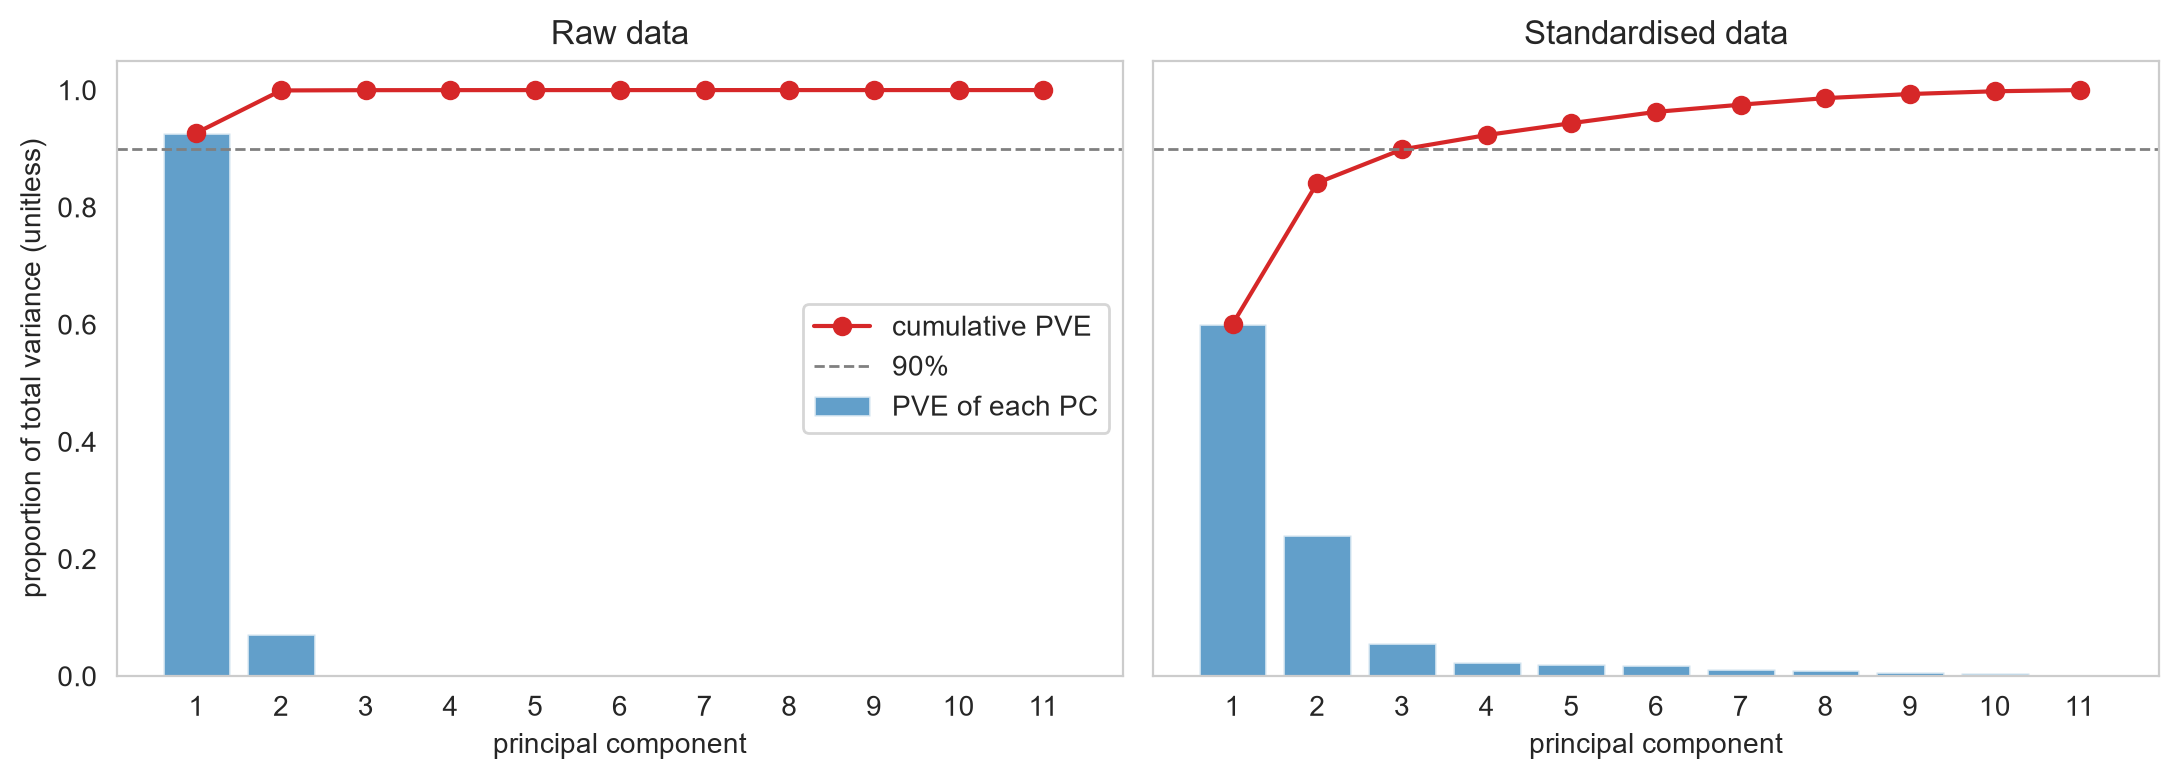

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tbl, title in zip(axes, [pve_raw, pve_std], ['Raw data', 'Standardised data']):
    ax.bar(range(1, 12), tbl['PVE'], color='tab:blue', alpha=0.7, label='PVE of each PC')
    ax.plot(range(1, 12), tbl['cumulative PVE'], 'o-', color='tab:red', label='cumulative PVE')
    ax.axhline(0.9, color='grey', ls='--', lw=1, label='90%')
    ax.set_title(title)
    ax.set_xlabel('principal component')
    ax.set_xticks(range(1, 12))
axes[0].set_ylabel('proportion of total variance (unitless)')
axes[0].legend(loc='center right')
plt.tight_layout()
plt.show();

In [22]:
# Unit experiment: express disp in litres instead of cubic inches and redo the raw PCA.
cars_litres = cars.copy()
cars_litres['disp'] = cars_litres['disp'] * 0.016387064
evals_l, evecs_l = eig_desc(np.cov(cars_litres, rowvar=False))
pc1_l = pd.Series(evecs_l[:, 0], index=cars.columns)
print(f'Raw PCA with disp in litres: PC1 PVE = {evals_l[0] / evals_l.sum():.4f}')
print('Largest PC1 loadings (unitless):')
print(pc1_l.reindex(pc1_l.abs().sort_values(ascending=False).index).head(3).round(3).to_string())

Raw PCA with disp in litres: PC1 PVE = 0.9955
Largest PC1 loadings (unitless):
hp     -0.997
mpg     0.068
disp   -0.023


**Result**: expressing `disp` in litres moves PC1 onto `hp` alone (loading 0.997, PVE 99.55%), so raw PCA reflects the scale of the units rather than the cars. Standardise whenever features have different units.

### Additional analysis - Part II

**B1. Loadings of PC1 to PC3**, raw and standardised (unitless; signs arbitrary).

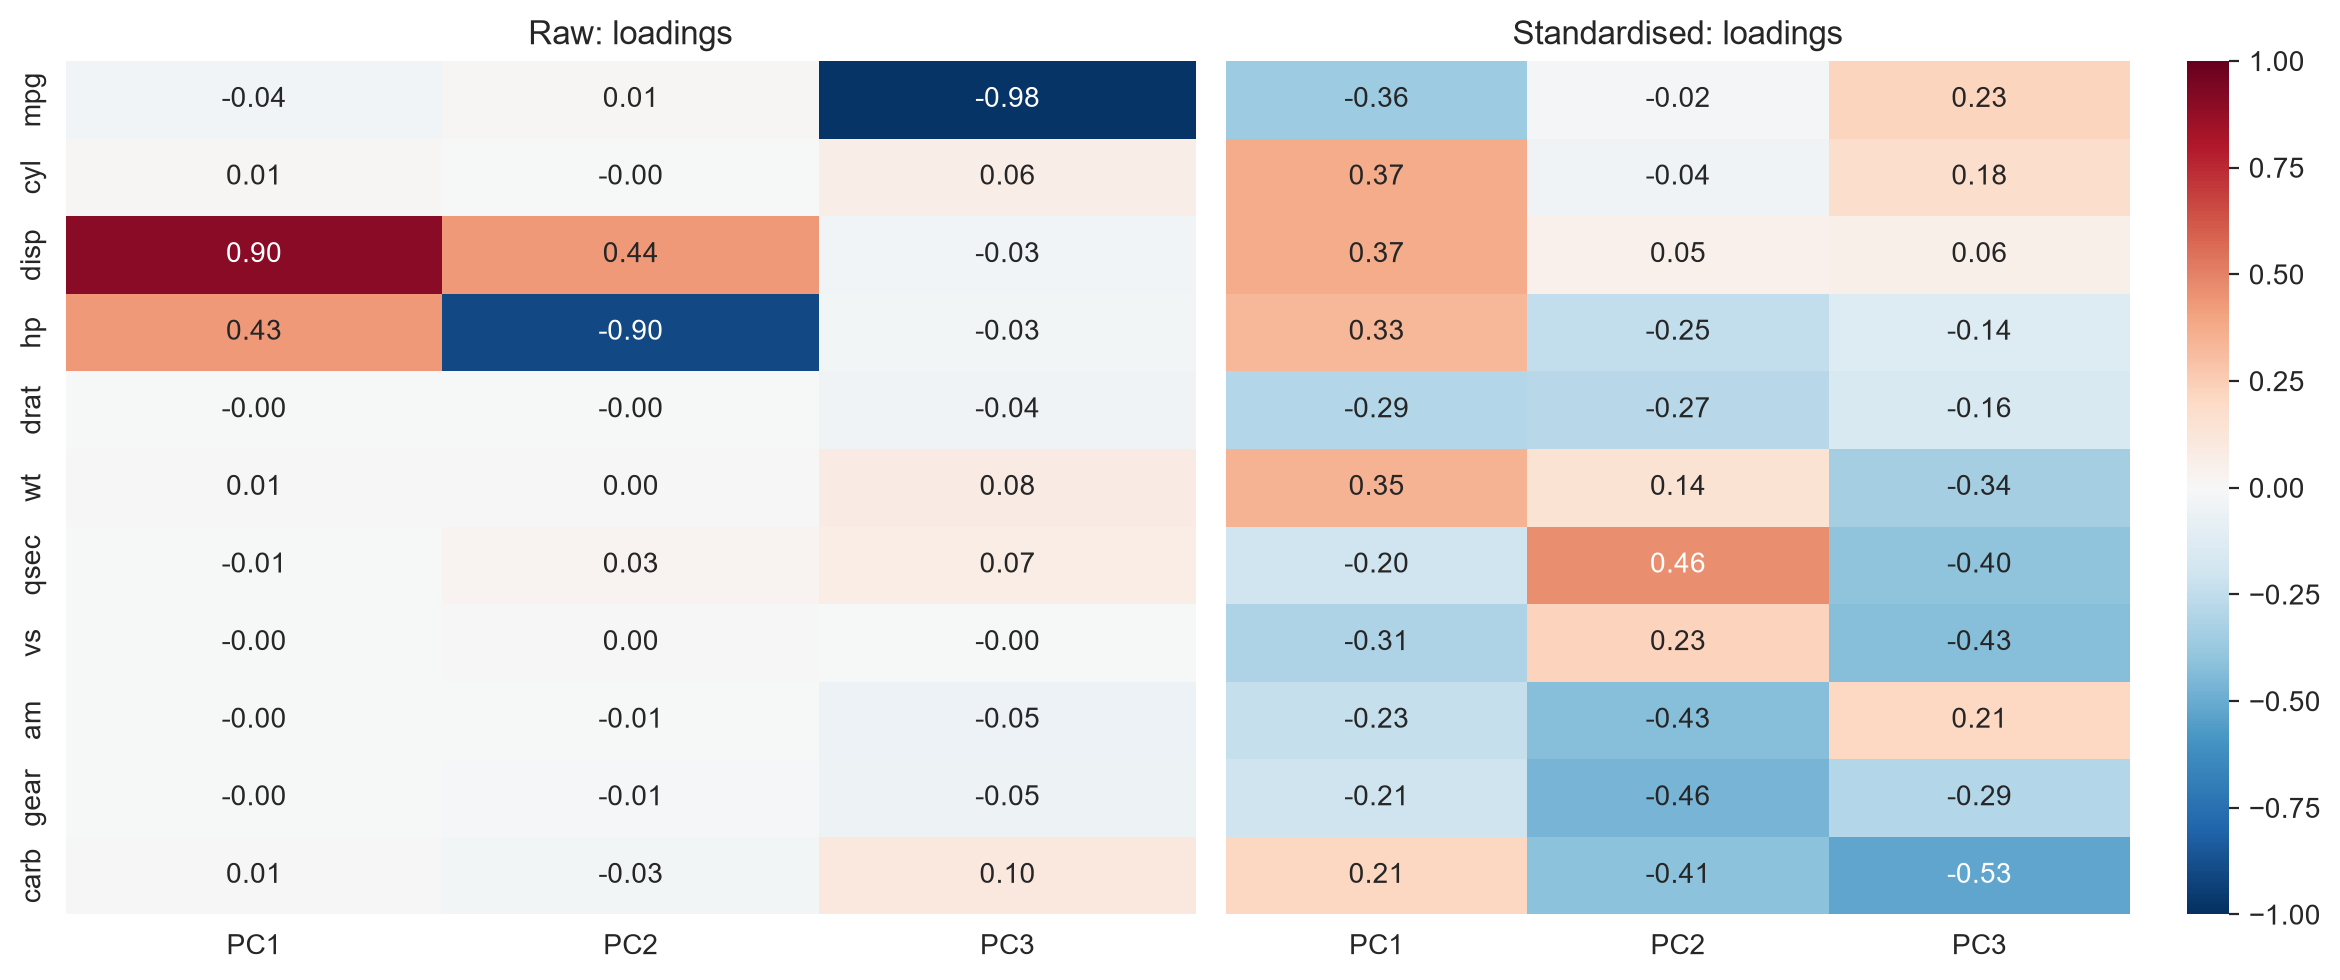

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, ld, title in zip(axes, [loadings_raw, loadings_std], ['Raw', 'Standardised']):
    sns.heatmap(ld[['PC1', 'PC2', 'PC3']], annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                cbar=ax is axes[1], ax=ax)
    ax.set_title(f'{title}: loadings')
plt.tight_layout()
plt.show();

**B2. PC1 vs PC2 scores**, coloured by number of cylinders. The raw plot is stretched along PC1 by `disp` and `hp`; the standardised plot uses both axes.

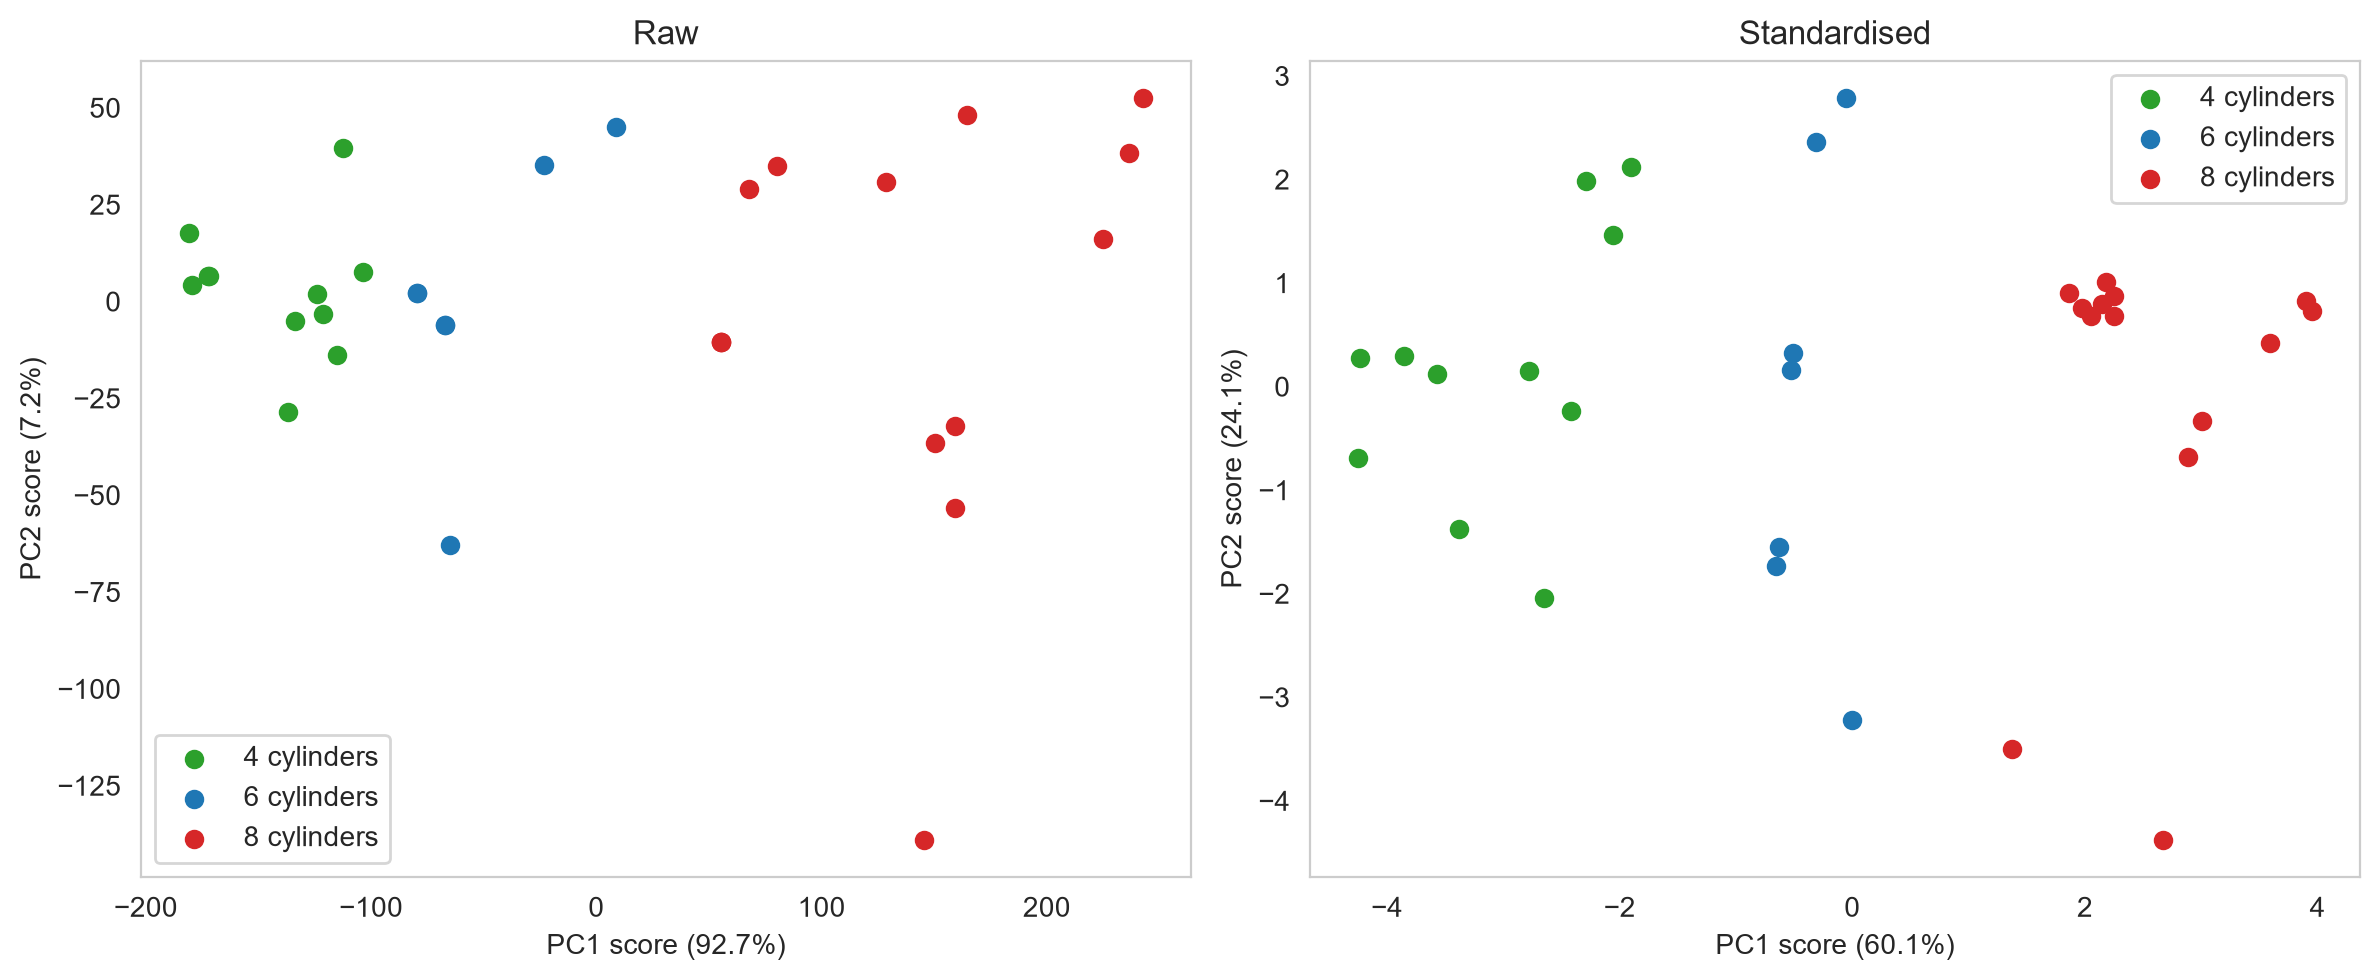

In [24]:
T_raw = (cars.values - cars.values.mean(axis=0)) @ evecs_raw[:, :2]
T_std = X_std @ evecs_std[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, T, pve_t, title in zip(axes, [T_raw, T_std], [pve_raw, pve_std], ['Raw', 'Standardised']):
    for n_cyl, colour in zip(sorted(cars['cyl'].unique()), ['tab:green', 'tab:blue', 'tab:red']):
        pick = (cars['cyl'] == n_cyl).values
        ax.scatter(T[pick, 0], T[pick, 1], color=colour, label=f'{n_cyl} cylinders')
    ax.set_xlabel(f'PC1 score ({pve_t["PVE"].iloc[0]:.1%})')
    ax.set_ylabel(f'PC2 score ({pve_t["PVE"].iloc[1]:.1%})')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show();

**Clustering on PC1.** PCA does not cluster, but its scores make groups easy to see and to find. k-means (2 clusters) on PC1 alone is compared with k-means on all 11 standardised features, and drawn as a positioning map of PC1 vs PC2 (arrows = loadings; each car is numbered by its row in the sheet, which has no names).

Cluster sizes on PC1 alone: [18 14]
Silhouette on PC1 alone (unitless): 0.673
Agreement with k-means on all 11 features, adjusted Rand index (1 = identical groups): 1.000

Cars per cylinder count in each cluster:
cluster   0   1
cyl            
4        11   0
6         7   0
8         0  14

Mean of each feature per cluster, in original units:
           0       1
mpg    23.97   15.10
cyl     4.78    8.00
disp  135.54  353.10
hp     98.06  209.21
drat    3.88    3.23
wt      2.61    4.00
qsec   18.69   16.77
vs      0.78    0.00
am      0.61    0.14
gear    4.00    3.29
carb    2.28    3.50

k = 2: silhouette on PC1 = 0.673; agreement with the cylinder count, adjusted Rand index = 0.688
k = 3: silhouette on PC1 = 0.688; agreement with the cylinder count, adjusted Rand index = 1.000


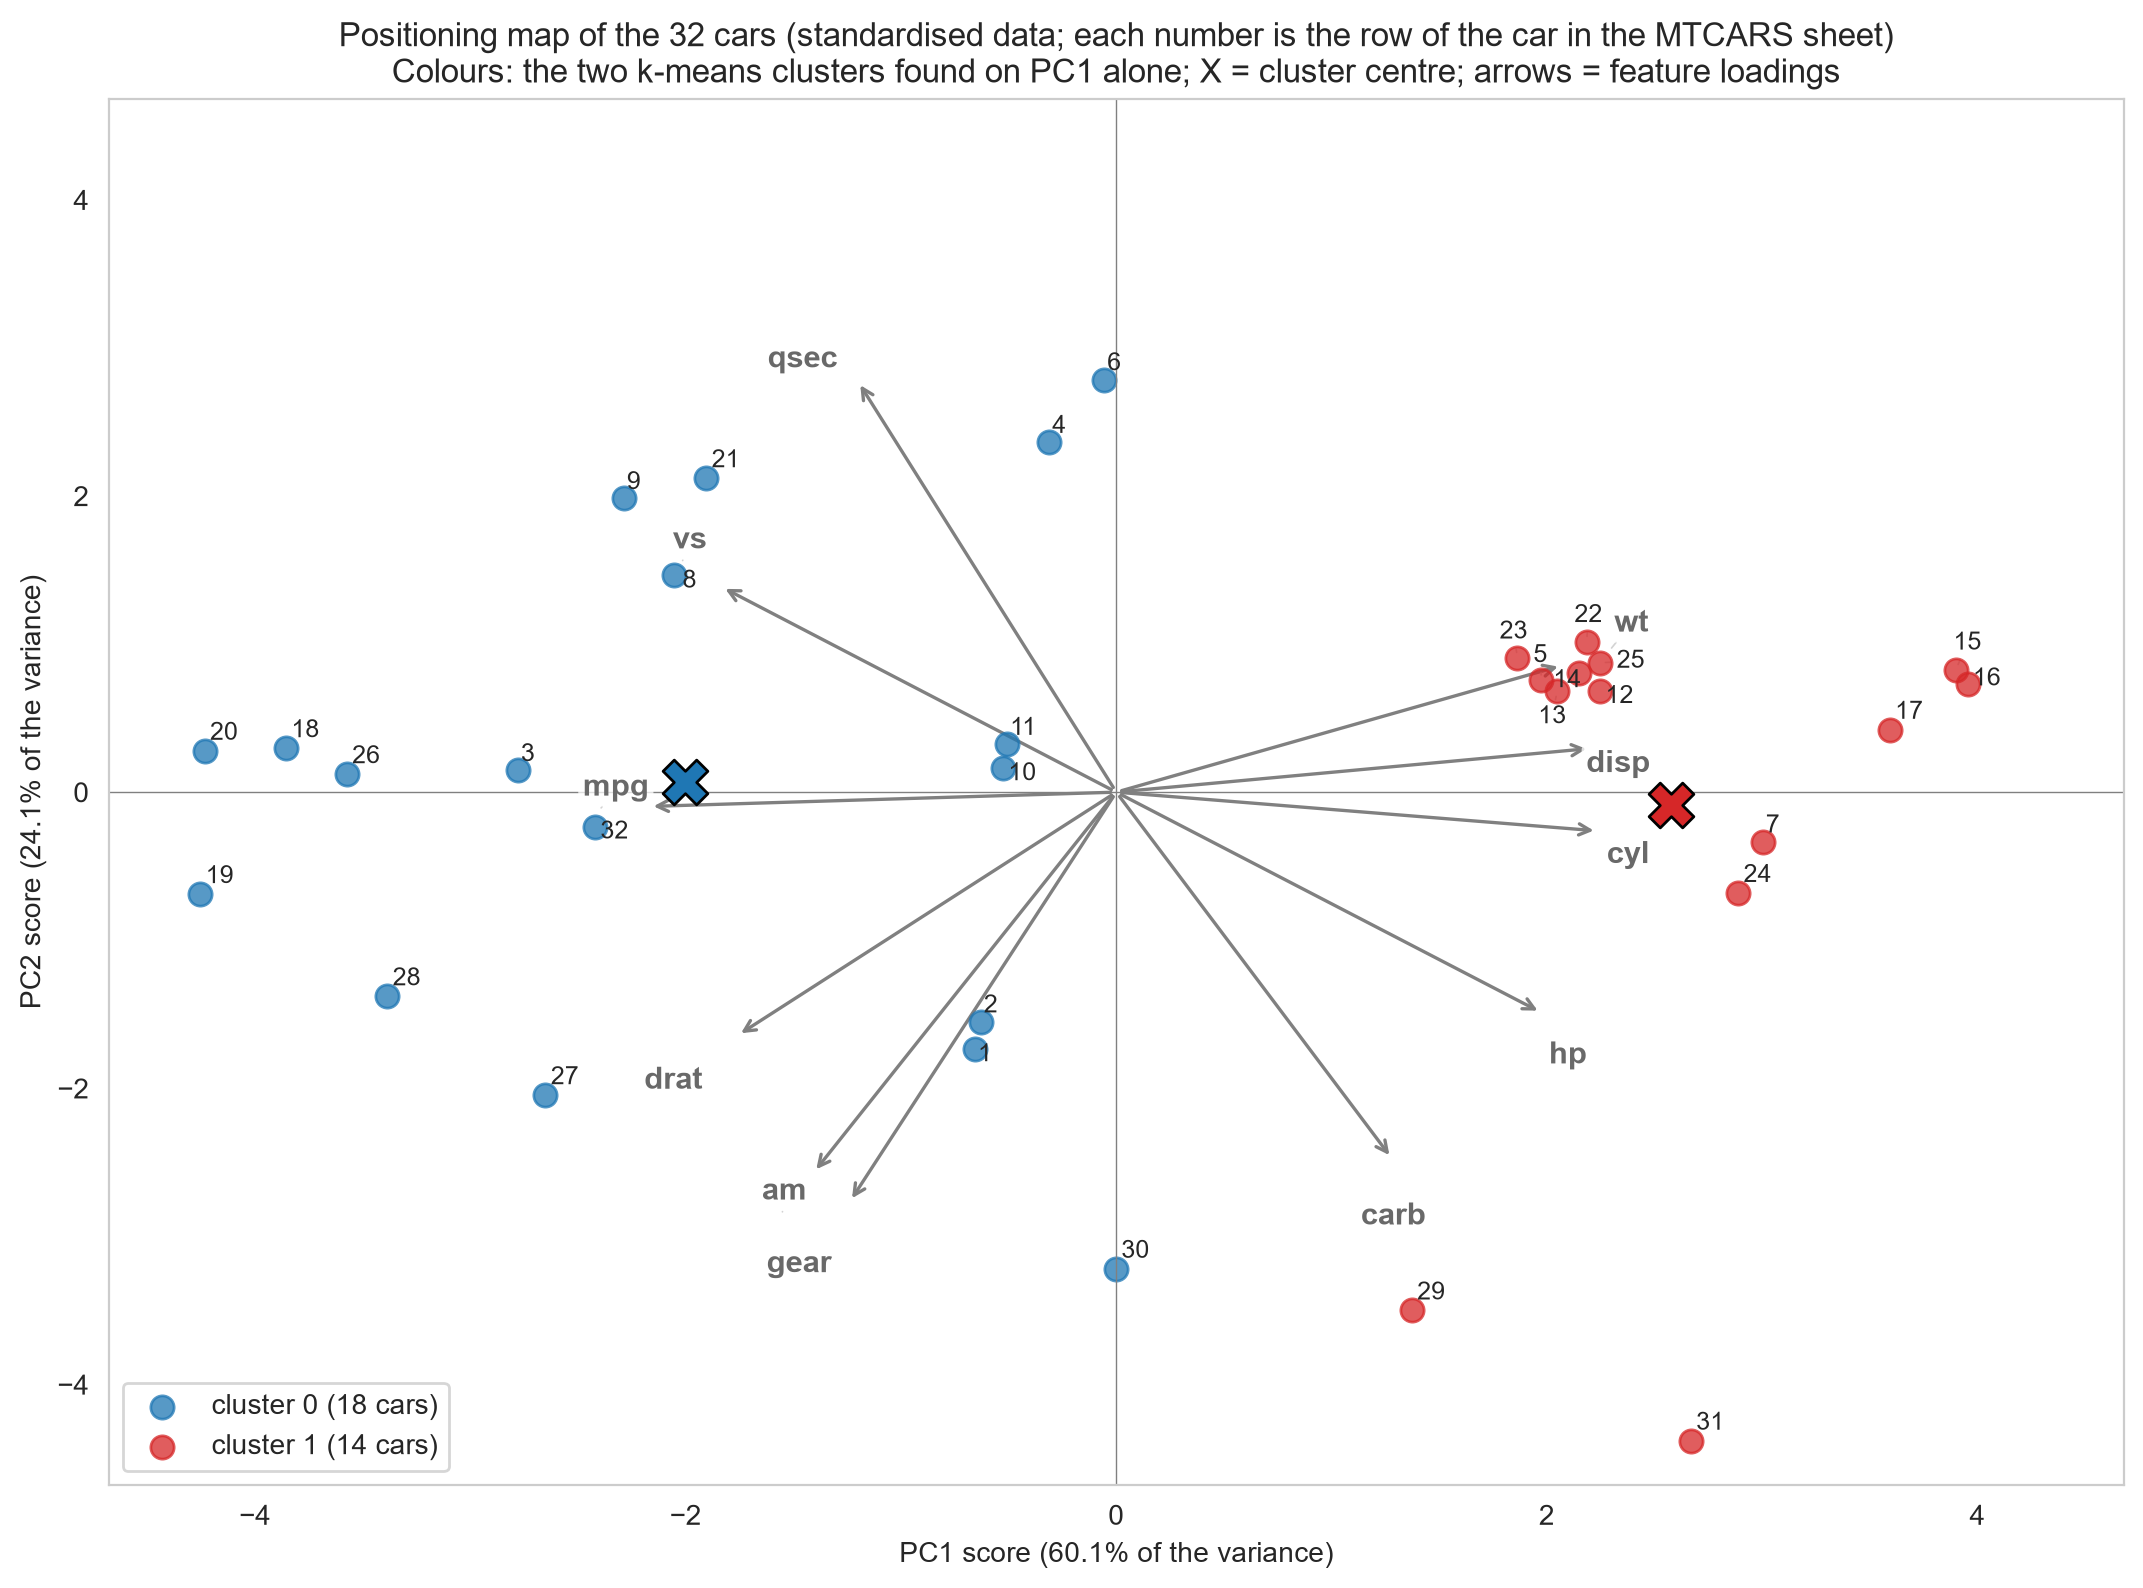

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

pc1 = T_std[:, :1]                                                      # PC1 scores of the standardised MTCARS data (Part II)
km_pc1 = KMeans(n_clusters=2, n_init=20, random_state=0).fit(pc1)
km_all = KMeans(n_clusters=2, n_init=20, random_state=0).fit(X_std)     # the same clustering on all 11 standardised features

print('Cluster sizes on PC1 alone:', np.bincount(km_pc1.labels_))
print(f'Silhouette on PC1 alone (unitless): {silhouette_score(pc1, km_pc1.labels_):.3f}')
print(f'Agreement with k-means on all 11 features, adjusted Rand index (1 = identical groups): {adjusted_rand_score(km_all.labels_, km_pc1.labels_):.3f}')
print()
print('Cars per cylinder count in each cluster:')
print(pd.crosstab(cars['cyl'], km_pc1.labels_, rownames=['cyl'], colnames=['cluster']))
print()
print('Mean of each feature per cluster, in original units:')
print(cars.groupby(km_pc1.labels_).mean().round(2).T)
print()
for k in (2, 3):
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(pc1)
    print(f'k = {k}: silhouette on PC1 = {silhouette_score(pc1, km.labels_):.3f}; agreement with the cylinder count, adjusted Rand index = {adjusted_rand_score(cars["cyl"], km.labels_):.3f}')

# Positioning map: every car placed by its PC1 and PC2 scores, coloured by the k-means cluster (found on PC1 alone).
# Arrows are the feature loadings in the PC1-PC2 plane (scaled up to be visible): a car sits toward the features it scores high on.
from adjustText import adjust_text

arrow_scale = 6
tips = evecs_std[:, :2] * arrow_scale
fig, ax = plt.subplots(figsize=(13, 9))
feature_names = []
for feature, tip in zip(cars.columns, tips):
    ax.annotate('', xy=tip, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='grey', lw=1.2), zorder=1)
    feature_names.append(ax.text(*(tip * 1.1), feature, color='dimgrey', fontsize=11, fontweight='bold', ha='center', va='center',
                                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.75), zorder=5))
for label, colour in zip([0, 1], ['tab:blue', 'tab:red']):
    pick = km_pc1.labels_ == label
    ax.scatter(T_std[pick, 0], T_std[pick, 1], color=colour, s=70, alpha=0.75, label=f'cluster {label} ({pick.sum()} cars)', zorder=2)
    ax.scatter(*T_std[pick, :2].mean(axis=0), color=colour, marker='X', s=260, edgecolor='black', zorder=3)   # cluster centre
names = [ax.text(x, y, str(row), fontsize=9, zorder=4) for row, (x, y) in enumerate(T_std[:, :2], start=1)]   # the sheet has no car names, so each car is numbered by its row (1-32)
adjust_text(names + feature_names, x=T_std[:, 0], y=T_std[:, 1], ax=ax, expand=(1.3, 1.6),
            arrowprops=dict(arrowstyle='-', color='lightgrey', lw=0.6))   # nudges the names apart and away from the points
lim = max(np.abs(T_std[:, :2]).max(), np.abs(tips).max() * 1.2) + 0.3
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel(f'PC1 score ({pve_std["PVE"].iloc[0]:.1%} of the variance)')
ax.set_ylabel(f'PC2 score ({pve_std["PVE"].iloc[1]:.1%} of the variance)')
ax.set_title('Positioning map of the 32 cars (standardised data; each number is the row of the car in the MTCARS sheet)\nColours: the two k-means clusters found on PC1 alone; X = cluster centre; arrows = feature loadings')
ax.legend(loc='lower left')
plt.show();

In [26]:
# What sits at each end of PC2? Mean of the features that load most on PC2, for the six cars lowest and highest on PC2
order = np.argsort(T_std[:, 1])
ends = pd.DataFrame({'six lowest on PC2': cars.iloc[order[:6]].mean(),
                     'six highest on PC2': cars.iloc[order[-6:]].mean(),
                     'all 32 cars': cars.mean()}).loc[['qsec', 'gear', 'am', 'carb', 'vs', 'hp']]
print('Sheet rows (1-based) of the six lowest:', sorted((order[:6] + 1).tolist()), ' and of the six highest:', sorted((order[-6:] + 1).tolist()))
print(ends.round(2).to_string())
print()
print(f'Correlation between the PC1 and PC2 scores: {round(np.corrcoef(T_std[:, 0], T_std[:, 1])[0, 1], 3) + 0.0:.3f}')
print(f'Mean PC2 score of cluster 0 and of cluster 1: {T_std[km_pc1.labels_ == 0, 1].mean():.2f} and {T_std[km_pc1.labels_ == 1, 1].mean():.2f} (standard deviation of PC2: {T_std[:, 1].std(ddof=1):.2f})')

Sheet rows (1-based) of the six lowest: [1, 2, 27, 29, 30, 31]  and of the six highest: [4, 6, 8, 9, 21, 22]
      six lowest on PC2  six highest on PC2  all 32 cars
qsec              15.80               19.91        17.85
gear               4.67                3.33         3.69
am                 1.00                0.00         0.41
carb               4.67                1.50         2.81
vs                 0.00                0.83         0.44
hp               180.83              103.17       146.69

Correlation between the PC1 and PC2 scores: 0.000
Mean PC2 score of cluster 0 and of cluster 1: 0.07 and -0.09 (standard deviation of PC2: 1.65)


**Reading the map.** "Large" = |loading| ≥ 0.30; signs are arbitrary, so the orientation drawn is followed.
- **PC1 (60.1%): size and power.** `cyl` (0.374), `disp` (0.368), `wt` (0.346), `hp` (0.330) against `mpg` (−0.363), `vs` (−0.307). It separates the two clusters.
- **PC2 (24.1%): gearing and acceleration.** `qsec` (0.463) against `gear` (−0.462), `am` (−0.429), `carb` (−0.414). Top six cars: automatic (`am` 0.00), 3.33 gears, 1.50 carburettors, quarter mile 19.91 s. Bottom six: manual (`am` 1.00), 4.67 gears, 4.67 carburettors, 15.80 s.
- **Uncorrelated scores**: the PC1 and PC2 scores have correlation 0.000, and PC2 does not separate the clusters (mean PC2 0.07 and −0.09, SD 1.65); it spreads the cars within each group.

**B3. Cross-check.** `sklearn.decomposition.PCA` gives the same PVEs, eigenvalues and loadings (up to sign) as the hand-built PCA.

In [27]:
def parity(data, evals, evecs):
    sk = PCA().fit(data)
    return {'max |PVE difference|': np.abs(sk.explained_variance_ratio_ - evals / evals.sum()).max(),
            'max |eigenvalue difference|': np.abs(sk.explained_variance_ - evals).max(),
            'max ||loading| difference|': np.abs(np.abs(sk.components_.T) - np.abs(evecs)).max()}

parity_tbl = pd.DataFrame({'raw': parity(cars, evals_raw, evecs_raw),
                           'standardised': parity(X_std, evals_std, evecs_std)})
print(parity_tbl.to_string(float_format=lambda v: f'{v:.2e}'))

                                 raw  standardised
max |PVE difference|        2.05e-17      4.44e-16
max |eigenvalue difference| 3.64e-12      8.88e-15
max ||loading| difference|  3.75e-12      4.12e-14


### Summary of Part II
- **Standardise first**: raw PC1 is almost only `disp` and `hp` (92.7%); standardised PC1 is 60.1% and three PCs reach 89.9%.
- **PC1**: size and power (`cyl`, `disp`, `wt`, `hp` against `mpg`, `vs`). **PC2**: gearing and acceleration (`qsec` against `gear`, `am`, `carb`). They are uncorrelated; only PC1 separates the groups.
- **Groups**: PC1 splits the 32 cars into 14 eight-cylinder cars (mean `mpg` 15.1 mile/gal, `hp` 209.2 hp) and 18 four- or six-cylinder cars (24.0 mile/gal, 98.1 hp). k-means on PC1 alone gives the same groups as on all 11 features (adjusted Rand index 1.000).
- **Caveats**: PCA does not cluster by itself; agreement with `cyl` is not independent (`cyl` feeds PC1); three clusters (4, 6, 8 cylinders) score slightly higher (silhouette 0.688 against 0.673); 32 cars only.
- **Check**: `sklearn` matches the hand-built PCA to about 4e-12 (table B3).